<a href="https://colab.research.google.com/github/DanielBR0612/supervised-machine-learning/blob/main/atividade5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Prática**
<font size=3>

- **Tema:** comparação e seleção de modelos.
- **Prazo de entrega:** 09 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

## **Enunciado:**
<font size=3>

Você atua como cientista de dados em um hospital. Sua equipe testou vários algoritmos para prever doenças cardíacas, e as acurácias médias parecem muito próximas. \
O modelos foram:
1. **Regressão Logística:** Linear, alto viés potencial (baseline).
2. **KNN (k-Nearest Neighbors):** Não-linear, sensível à escala.
3. **Árvore de Decisão:** Alta variância, baixo viés.
4. **Random Forest:** Ensemble (busca reduzir a variância da árvore).

Seu chefe perguntou: "Qual modelo devemos colocar em produção com segurança?". Sua missão é usar estatística no dataset [`breast-cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). Para isso, realize os seguintes passos:


### **1º Passo:**
<font size=3>
    
1. Carregue o dataset;
2. Realize um pré-processamento básico (tratamento de nulos se houver, [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) é obrigatório para o KNN e Regressão Logística);
3. Implemente um loop de validação cruzada com [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) com a estrafificação [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) para 10 *folds* e `random_state` fixo;
4. Armazene a acurácia de cada modelo em cada um dos 10 folds.

In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [35]:
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target)

X = X.dropna(axis=1)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [36]:
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

pipeline_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

In [37]:
modelos = {
    'Regressão Logística': pipeline_logreg,
    'KNN': pipeline_knn,
    'Árvore de Decisão': pipeline_tree,
    'Random Forest': pipeline_rf
}

resultados = {}

print("Iniciando a validação cruzada nos 10 folds...\n")

for nome_modelo, pipeline in modelos.items():
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

    resultados[nome_modelo] = scores

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia Média: {scores.mean():.4f} (Desvio Padrão: {scores.std():.4f})\n")

df_resultados = pd.DataFrame(resultados)
df_resultados.index = [f'Fold {i+1}' for i in range(10)]

print("--- Tabela Completa de Acurácias por Fold ---")
print(df_resultados)

Iniciando a validação cruzada nos 10 folds...

=== Regressão Logística ===
Acurácia Média: 0.9754 (Desvio Padrão: 0.0195)

=== KNN ===
Acurácia Média: 0.9701 (Desvio Padrão: 0.0176)

=== Árvore de Decisão ===
Acurácia Média: 0.9262 (Desvio Padrão: 0.0233)

=== Random Forest ===
Acurácia Média: 0.9561 (Desvio Padrão: 0.0239)

--- Tabela Completa de Acurácias por Fold ---
         Regressão Logística       KNN  Árvore de Decisão  Random Forest
Fold 1              0.982456  0.982456           0.912281       0.947368
Fold 2              0.982456  0.982456           0.929825       0.982456
Fold 3              0.947368  0.964912           0.964912       0.964912
Fold 4              0.947368  0.947368           0.894737       0.912281
Fold 5              0.982456  0.947368           0.894737       0.947368
Fold 6              0.947368  0.947368           0.964912       0.964912
Fold 7              1.000000  1.000000           0.929825       0.964912
Fold 8              0.982456  0.982456     

### **2º Passo:**
<font size=3>
    
1. Gere um **Boxplot** comparando as distribuições das acurácias dos 4 modelos. Visualmente, existe um vencedor claro? **Escreva** em uma **célula _markdown_**;
2. Aplique o **Teste de t** par a par com **correção de Bonferroni**;
3. Algum modelo é estatisticamente superior aos outros? Ou existem "empates técnicos"? **Escreva** em uma **célula _markdown_**.

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

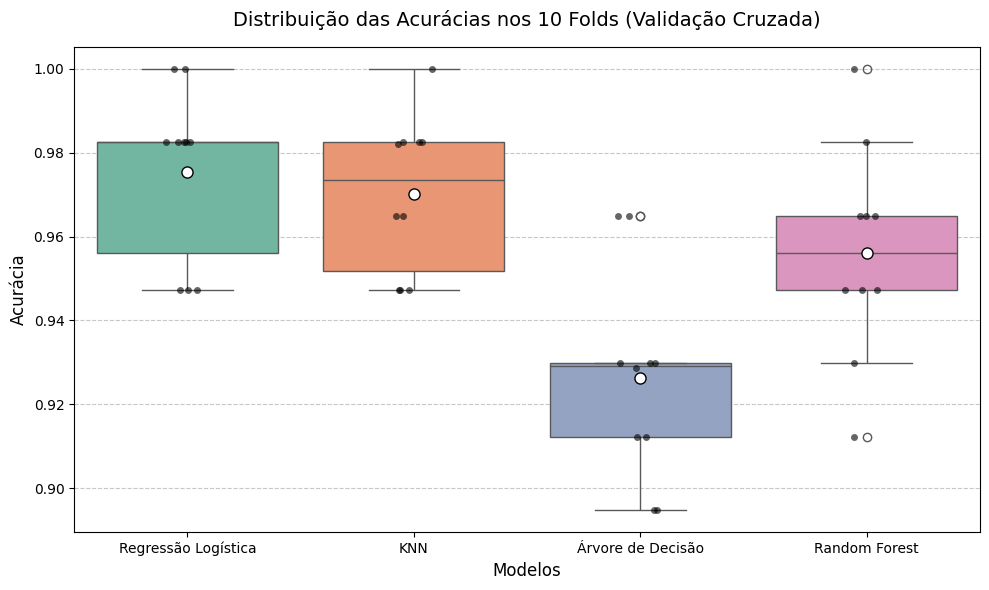

In [49]:
df_plot = pd.DataFrame(resultados)

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_plot, palette="Set2", showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

sns.stripplot(data=df_plot, color='black', alpha=0.6, jitter=True, size=5)

plt.title('Distribuição das Acurácias nos 10 Folds (Validação Cruzada)', fontsize=14, pad=15)
plt.ylabel('Acurácia', fontsize=12)
plt.xlabel('Modelos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Visualmente, da para perceber que a regressão logística e o KNN se destacaram em relação aos outros 2 modelos, sendo a árvore de decisão o pior desemepenho.

In [40]:
names = list(models.keys())
k_models = len(names)
n_campare = (k_models*(k_models - 1))/2

alpha_original = 0.05
alpha_bonferroni = alpha_original / n_campare

matriz_p_t = np.ones((k_models, k_models))

for i in range(k_models):
    for j in range(k_models):
        if i == j:
            continue

        _, p_val_t = stats.ttest_rel(df_resultados[names[i]], df_resultados[names[j]])
        matriz_p_t[i, j] = p_val_t

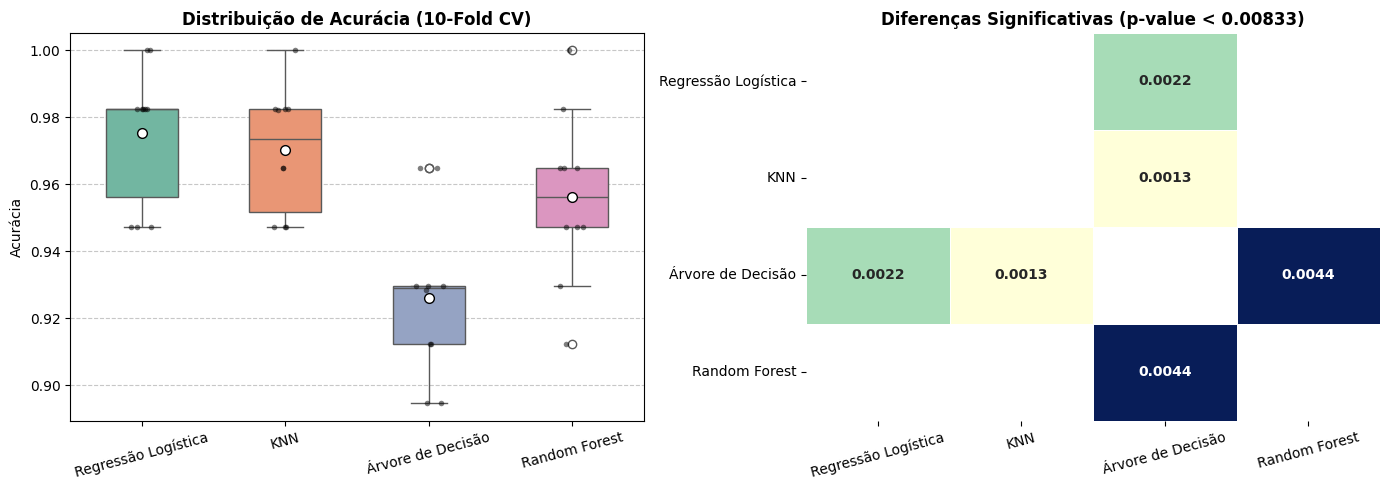

In [41]:
df_p_t = pd.DataFrame(matriz_p_t, index=names, columns=names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_resultados, palette="Set2", width=0.5, ax=ax1,
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"})

sns.stripplot(data=df_resultados, color='black', alpha=0.5, jitter=True, size=4, ax=ax1)

ax1.set_title("Distribuição de Acurácia (10-Fold CV)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Acurácia")
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

mask = df_p_t >= alpha_bonferroni

sns.heatmap(df_p_t, annot=True, fmt=".4f", cmap="YlGnBu",
            mask=mask, cbar=False, linewidths=.5, ax=ax2,
            annot_kws={"weight": "bold"})

ax2.set_title(f"Diferenças Significativas (p-value < {alpha_bonferroni:.5f})", fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Tem empate tecnico entre regressão logística e KNN

### **3º Passo:**
<font size=3>

1. Selecione a **Árvore de Decisão** e a **Regressão Logística**;
2. Utilize a técnica de decomposição de erro (MSE das probabilidades) vista em aula;
3. Gere o gráfico de barras comparando $Viés^2$ e $Variância$ para estes dois modelos;
4. Qual modelo sofre mais de *Overfitting*? Isso condiz com a teoria? **Escreva** em uma **célula _markdown_**.


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
def vies_variancia(model, X_train, y_train, X_test, y_test, n_iterations=100):

    y_pred_probs = []

    for _ in range(n_iterations):
        index_bootstrap = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_train_boot, y_train_boot = X_train.iloc[index_bootstrap], y_train.iloc[index_bootstrap]

        model_clone = clone(model)
        model_clone.fit(X_train_boot, y_train_boot)

        y_pred_probs.append(model_clone.predict_proba(X_test)[:, 1])

    y_pred_probs = np.array(y_pred_probs)

    mean_pred = np.mean(y_pred_probs, axis=0)
    bias2 = np.mean((mean_pred - y_test)**2)
    variance = np.mean(np.var(y_pred_probs, axis=0))

    return bias2, variance

In [45]:
models = {
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

results_decomposition = {}

In [46]:
print("Executando simulação de Viés-Variância (100 rodadas de Bootstrap)...\n")
for nome, modelo in models.items():

    b2, var = vies_variancia(modelo, X_train, y_train, X_test, y_test)

    results_decomposition[nome] = {'Viés²': b2, 'Variância': var, 'Erro Total Estimado': b2 + var}
    print(f"{nome}: Viés² = {b2:.4f}, Variância = {var:.4f}")

Executando simulação de Viés-Variância (100 rodadas de Bootstrap)...

Árvore de Decisão: Viés² = 0.0321, Variância = 0.0332
Regressão Logística: Viés² = 0.0167, Variância = 0.0014


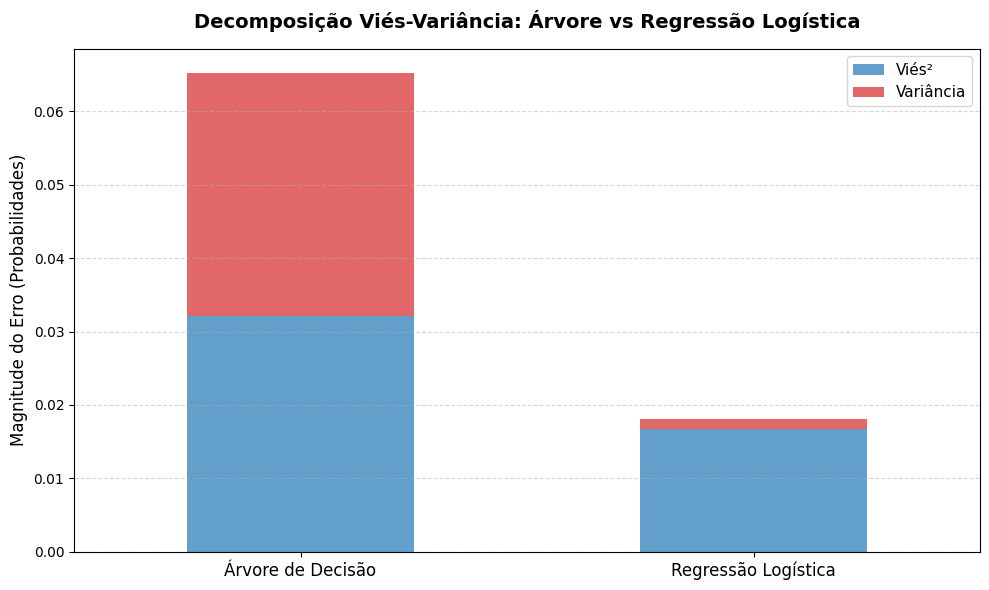

In [50]:
df_results = pd.DataFrame(results_decomposition).T

df_results[['Viés²', 'Variância']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['tab:blue','tab:red'], alpha=0.7)

plt.title("Decomposição Viés-Variância: Árvore vs Regressão Logística", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Magnitude do Erro (Probabilidades)", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A arvore de decisão sofreu overfitting, ja que a variancia é muito alta, mostrando que ela se adequou minuciosamente aos ruídos, o que faz sentido pois é uma arvore profunda